# Tools for visualizing data<a href="#Tools-for-visualizing-data" class="anchor-link">¶</a>

This notebook is a "tour" of just a few of the data visualization
capabilities available to you in Python. It focuses on two packages:
[Bokeh](https://blog.modeanalytics.com/python-data-visualization-libraries/)
for creating *interactive* plots and *\[Seaborn\]* for creating "static"
(or non-interactive) plots. The former is really where the ability to
develop *programmatic* visualizations, that is, code that generates
graphics, really shines. But the latter is important in printed
materials and reports. So, both techniques should be a core part of your
toolbox.

With that, let's get started!

> **Note 1.** Since visualizations are not amenable to autograding, this
> notebook is more of a demo of what you can do. It doesn't require you
> to write any code on your own. However, we strongly encourage you to
> spend some time experimenting with the basic methods here and generate
> some variations on your own. Once you start, you'll find it's more
> than a little fun!
>
> **Note 2.** Though designed for R programs, Hadley Wickham has an
> [excellent description of many of the principles in this
> notebook](http://r4ds.had.co.nz/data-visualisation.html).

## Part 0: Downloading some data to visualize<a href="#Part-0:-Downloading-some-data-to-visualize"
class="anchor-link">¶</a>

For the demos in this notebook, we'll need the Iris dataset. The
following code cell downloads it for you.

In \[1\]:

    import requests
    import os
    import hashlib
    import io

    def download(file, url_suffix=None, checksum=None):
        if url_suffix is None:
            url_suffix = file
            
        if not os.path.exists(file):
            url = 'https://cse6040.gatech.edu/datasets/{}'.format(url_suffix)
            print("Downloading: {} ...".format(url))
            r = requests.get(url)
            with open(file, 'w', encoding=r.encoding) as f:
                f.write(r.text)
                
        if checksum is not None:
            with io.open(file, 'r', encoding='utf-8', errors='replace') as f:
                body = f.read()
                body_checksum = hashlib.md5(body.encode('utf-8')).hexdigest()
                assert body_checksum == checksum, \
                    "Downloaded file '{}' has incorrect checksum: '{}' instead of '{}'".format(file, body_checksum, checksum)
        
        print("'{}' is ready!".format(file))
        
    datasets = {'iris.csv': ('tidy', 'd1175c032e1042bec7f974c91e4a65ae'),
                'tips.csv': ('seaborn-data', 'ee24adf668f8946d4b00d3e28e470c82'),
                'anscombe.csv': ('seaborn-data', '2c824795f5d51593ca7d660986aefb87'),
                'titanic.csv': ('seaborn-data', '56f29cc0b807cb970a914ed075227f94')
               }

    for filename, (category, checksum) in datasets.items():
        download(filename, url_suffix='{}/{}'.format(category, filename), checksum=checksum)
        
    print("\n(All data appears to be ready.)")

    'iris.csv' is ready!
    'tips.csv' is ready!
    'anscombe.csv' is ready!
    'titanic.csv' is ready!

    (All data appears to be ready.)

# Part 1: Bokeh and the Grammar of Graphics ("lite")<a href="#Part-1:-Bokeh-and-the-Grammar-of-Graphics-(%22lite%22)"
class="anchor-link">¶</a>

Let's start with some methods for creating an interactive visualization
in Python and Jupyter, based on the
[Bokeh](https://bokeh.pydata.org/en/latest/) package. It generates
JavaScript-based visualizations, which you can then run in a web
browser, without you having to know or write any JS yourself. The
web-friendly aspect of Bokeh makes it an especially good package for
creating interactive visualizations in a Jupyter notebook, since it's
also browser-based.

The design and use of Bokeh is based on Leland Wilkinson's Grammar of
Graphics (GoG).

> If you've encountered GoG ideas before, it was probably when using the
> best known implementation of GoG, namely, Hadley Wickham's R package,
> [ggplot2](http://ggplot2.org/).

## Setup<a href="#Setup" class="anchor-link">¶</a>

Here are the modules we'll need for this notebook:

In \[2\]:

    from IPython.display import display, Markdown
    import pandas as pd
    import bokeh

Bokeh is designed to output HTML, which you can then embed in any
website. To embed Bokeh output into a Jupyter notebook, we need to do
the following:

In \[3\]:

    from bokeh.io import output_notebook
    from bokeh.io import show
    output_notebook ()

<a href="https://bokeh.pydata.org"
class="bk-logo bk-logo-small bk-logo-notebook" target="_blank"></a>
<span id="3879b657-ea08-4564-8074-27ab68c4079a">Loading BokehJS
...</span>

## Philosophy: Grammar of Graphics<a href="#Philosophy:-Grammar-of-Graphics" class="anchor-link">¶</a>

[The Grammar of
Graphics](http://www.springer.com.prx.library.gatech.edu/us/book/9780387245447)
is an idea of Leland Wilkinson. Its basic idea is that the way most
people think about visualizing data is ad hoc and unsystematic, whereas
there exists in fact a "formal language" for describing visual displays.

The reason why this idea is important and powerful in the context of our
course is that it makes visualization more systematic, thereby making it
easier to create those visualizations through code.

The high-level concept is simple:

1.  Start with a (tidy) data set.
2.  Transform it into a new (tidy) data set.
3.  Map variables to geometric objects (e.g., bars, points, lines) or
    other aesthetic "flourishes" (e.g., color).
4.  Rescale or transform the visual coordinate system.
5.  Render and enjoy!

![From data to
visualization](http://r4ds.had.co.nz/images/visualization-grammar-3.png)

> This image is "liberated" from:
> <http://r4ds.had.co.nz/data-visualisation.html>

## HoloViews<a href="#HoloViews" class="anchor-link">¶</a>

Before seeing Bokeh directly, let's start with an easier way to take
advantage of Bokeh, which is through a higher-level interface known as
[HoloViews](http://holoviews.org/). HoloViews provides a simplified
interface suitable for "canned" charts.

To see it in action, let's load the Iris data set and study
relationships among its variables, such as petal length vs. petal width.

The cells below demonstrate histograms, simple scatter plots, and box
plots. However, there is a much larger gallery of options:
<http://holoviews.org/reference/index.html>

In \[4\]:

    flora = pd.read_csv ('iris.csv')
    display (flora.head ())

|     | sepal length | sepal width | petal length | petal width | species     |
|-----|--------------|-------------|--------------|-------------|-------------|
| 0   | 5.1          | 3.5         | 1.4          | 0.2         | Iris-setosa |
| 1   | 4.9          | 3.0         | 1.4          | 0.2         | Iris-setosa |
| 2   | 4.7          | 3.2         | 1.3          | 0.2         | Iris-setosa |
| 3   | 4.6          | 3.1         | 1.5          | 0.2         | Iris-setosa |
| 4   | 5.0          | 3.6         | 1.4          | 0.2         | Iris-setosa |

In \[5\]:

    from bokeh.io import show
    import holoviews as hv
    import numpy as np
    hv.extension('bokeh')

<img
src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz%0AAAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB%0AVHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt%0AtI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3%0AnFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3%0AETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD%0AlG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo%0AG62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ%0Ax1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo%0AGTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC%0A4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy%0ABGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL%0AQYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI%0AOoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm%0A2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ%0AzsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv%0AHnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ%0Anoie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/%0AKzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu%0AUkf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6%0AV/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O%0AUyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF%0A71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3%0AltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N%0AaedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR%0A1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK%0A9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM%0ACwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf%0AxrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09%0Ae0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4%0Ay2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j%0A2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F%0AeKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz%0AidWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN%0AVM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y%0ANCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij%0ANRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP%0AfFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP%0AHaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt%0ALt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG%0AsjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF%0AJqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53%0A0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l%0A18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc%0AefUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A%0AKG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ%0AlIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW%0AnvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE%0AllRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y%0AciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p%0AxqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0%0ATz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9WUhfBaC2ibcEBYm7a7x+ukrBMNcEZggyR0TE%0AT8zUPjikQ4VosQZbTpS4vqizBKvqmvjsqnpfzaZyx9JPiz1/bfGKdgD45XB1zoIMzYbfTdS/NClB%0AGct0USiY3YL/g0LHy/uq/Ef6uo5+n0R/vyhp17Klpge763f8rMu6YU/zrn2nml+2WtH+Z+5IAAFc%0A2bUTdTDOSNa9+cQY7YLsOIXhevEkCvzph7a8laecz/Un/z4/Ae04XeL3UQb57IwU9ZDr9UuKVajv%0Anxp1+1UVIo/LjztZkKH59fO3G/JemqCfmaCRqbqbd90ZZ8FfjtkfAyD0J/9+C2h1hDwsSxvGjNDc%0Ab4zk5NfrSwiQblLHzZhg+Jf4aPlUwpDqkQqa9nimbt1/TDH8OitGMaQnj+RJS6B1fbF7SY1TqO5v%0A/v0WAADl1f7zokgS7s7VT2DZ7pegUjBM7mjtiDZbcN4j0YrHH0rXpCtY0qPX0cVL0rv5jv/ZXend%0A0u/EESYBAFBU4T4Qa5TflZOhTe7pmKpaP8kCVUVw1+yhXfJWvn1P3hnXi33JsTN6PnP3hHZ8Z3/h%0AaLHzmkNPuPj7Bc/F/Q38CwjTpSwQXgE4Vmwry9tpfq/ZFgqFMy4AVDtCvi8rvMvOmv0N4YwbVgEA%0AsPM72/KVnzfspmH7HQGCRLG2yL1+z8XwvPcdCbsAANh+xPzstgMtxeGKt+6MK3/tacfvwhWvIwMi%0AoKEBtm0H7W+UVfkc/Y1V0BhoPlDr/w1w/eu1vjIgAgDg22OtX6/eYfnEz/focrZTHAFR+PSs56/7%0Aq32nwpjazxgwAQCwcU/T62t3WL7r6/jVRa6/byp1rei+Z98ZUAEAhEPHPc8fKnTU9nbgtnOe8h0l%0A9hcGIqmODLQAHCy2Xti6v/XNRivf43f4fFvIteu854+VHnR7q9tfBlwAAGz+pnndB9vM26UebAe8%0ASLHujPOTPVW+rwY+sxskAAC2HrA8t2Vvc7ffP1r9o+vwR2dcr92InIAbKKC1FZ5tB1tf+/G8p8sv%0AN/9Q5zd/XR34LYCwV5JdccMEAMDBk45DH243r/X4xGvqxFa/GNpS7n6rwOwNWwHVE26oAADYurf1%0Azx/utOzt+DMKYM0p17YtZZ5VNzqfsB2HewG1WXE8PoZ7gOclbTIvynZf9JV+fqZtfgs/8F/Nu5rB%0AEIBmJ+8QRMmpU7EzGRsf2FzuePqYRbzh/zE26EwdrT10f6r6o8HOYzCJB9Dpff8tbnGLG8L/A/WE%0AroTBs2RqAAAAAElFTkSuQmCC"
style="height:25px; border-radius:12px; display: inline-block; float: left; vertical-align: middle" />
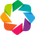

### 1. Histogram<a href="#1.-Histogram" class="anchor-link">¶</a>

-   The Histogram(f, e) can takes two arguments, frequencies and edges
    (bin boundaries).
-   These can easily be created using numpy's histogram function as
    illustrated below.
-   The plot is interactive and comes with a bunch of tools. You can
    customize these tools as well; for your many options, see
    <http://bokeh.pydata.org/en/latest/docs/user_guide/tools.html>.

> You may see some warnings appear in a pink-shaded box. You can ignore
> these. They are caused by some slightly older version of the Bokeh
> library that is running on Vocareum.

In \[6\]:

    frequencies, edges = np.histogram(flora['petal width'], bins = 5)
    hv.Histogram(frequencies, edges, label = 'Histogram')

    WARNING:root:Histogram: Histogram edges should be supplied as a tuple along with the values, passing the edges will be deprecated in holoviews 2.0.
    /usr/local/lib/python3.6/site-packages/bokeh/core/json_encoder.py:80: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
      elif np.issubdtype(type(obj), np.float):

Out\[6\]:

A user can interact with the chart above using the tools shown on the
right-hand side. Indeed, you can select or customize these tools! You'll
see an example below.

### 2. ScatterPlot<a href="#2.-ScatterPlot" class="anchor-link">¶</a>

In \[7\]:

    hv.Scatter(flora[['petal width','sepal length']],label = 'Scatter plot')

Out\[7\]:

### 3. BoxPlot<a href="#3.-BoxPlot" class="anchor-link">¶</a>

In \[8\]:

    hv.BoxWhisker(flora['sepal length'], label = "Box whiskers plot")

Out\[8\]:

## Mid-level charts: the Plotting interface<a href="#Mid-level-charts:-the-Plotting-interface"
class="anchor-link">¶</a>

Beyond the canned methods above, Bokeh provides a "mid-level" interface
that more directly exposes the grammar of graphics methodology for
constructing visual displays.

The basic procedure is

-   Create a blank canvas by calling `bokeh.plotting.figure`
-   Add glyphs, which are geometric shapes.

> For a full list of glyphs, refer to the methods of
> `bokeh.plotting.figure`:
> <http://bokeh.pydata.org/en/latest/docs/reference/plotting.html>

In \[9\]:

    from bokeh.plotting import figure

    # Create a canvas with a specific set of tools for the user:
    TOOLS = 'pan,box_zoom,wheel_zoom,lasso_select,save,reset,help'
    p = figure(width=500, height=500, tools=TOOLS)
    print(p)

    Figure(id='8a49e441-503c-445b-a571-5360eab653ed', ...)

In \[10\]:

    # Add one or more glyphs
    p.triangle(x=flora['petal width'], y=flora['petal length'])

Out\[10\]:

**GlyphRenderer**(

id = '0686e0d3-4f1c-4e31-828a-570095c61fe6', <span
id="dc4c79a1-0a97-408d-a514-df89d206ef39"
style="cursor: pointer;">…)</span>

data_source = ColumnDataSource(id='7dd33488-b6f9-4f44-a6e8-799dc9cd7345',
...),

glyph = Triangle(id='88f8f589-8293-4e38-a885-63312f34c7e7', ...),

hover_glyph = None,

js_event_callbacks = {},

js_property_callbacks = {},

level = 'glyph',

muted = False,

muted_glyph = None,

name = None,

nonselection_glyph = Triangle(id='c230f056-338e-4914-a5b5-5a83fe833edd',
...),

selection_glyph = None,

subscribed_events = \[\],

tags = \[\],

view = CDSView(id='fb48b602-6da8-408b-be33-b27125592269', ...),

visible = True,

x_range_name = 'default',

y_range_name = 'default')

In \[11\]:

    show(p)

**Using data from Pandas.** Here is another way to do the same thing,
but using a Pandas data frame as input.

In \[12\]:

    from bokeh.models import ColumnDataSource

    data=ColumnDataSource(flora)
    p=figure()
    p.triangle(source=data, x='petal width', y='petal length')
    show(p)

**Color maps.** Let's make a map that assigns each unique species its
own color. Incidentally, there are many choices of colors!
<http://bokeh.pydata.org/en/latest/docs/reference/palettes.html>

In \[13\]:

    # Determine the unique species
    unique_species = flora['species'].unique()
    print(unique_species)

    ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

In \[14\]:

    # Map each species with a unique color
    from bokeh.palettes import brewer
    color_map = dict(zip(unique_species, brewer['Dark2'][len(unique_species)]))
    print(color_map)

    {'Iris-setosa': '#1b9e77', 'Iris-versicolor': '#d95f02', 'Iris-virginica': '#7570b3'}

In \[15\]:

    # Create data sources for each species
    data_sources = {}
    for s in unique_species:
        data_sources[s] = ColumnDataSource(flora[flora['species']==s])

Now we can more programmatically generate the same plot as above, but
use a unique color for each species.

In \[16\]:

    p = figure()
    for s in unique_species:
        p.triangle(source=data_sources[s], x='petal width', y='petal length', color=color_map[s])
    show(p)

That's just a quick tour of what you can do with Bokeh. We will
incorporate it into some of our future labs. At this point, we'd
encourage you to experiment with the code cells above and try generating
your own variations!

# Part 2: Static visualizations using Seaborn<a href="#Part-2:-Static-visualizations-using-Seaborn"
class="anchor-link">¶</a>

Parts of this lab are taken from publicly available Seaborn tutorials.
<http://seaborn.pydata.org/tutorial/distributions.html>

They were adapted for use in this notebook by [Shang-Tse Chen at Georgia
Tech](https://www.cc.gatech.edu/~schen351).

In \[17\]:

    import seaborn as sns

    # The following Jupyter "magic" command forces plots to appear inline
    # within the notebook.
    %matplotlib inline

When dealing with a set of data, often the first thing we want to do is
get a sense for how the variables are distributed. Here, we will look at
some of the tools in seborn for examining univariate and bivariate
distributions.

### Plotting univariate distributions<a href="#Plotting-univariate-distributions" class="anchor-link">¶</a>

distplot() function will draw a histogram and fit a kernel density
estimate

In \[18\]:

    import numpy as np
    x = np.random.normal(size=100)
    sns.distplot(x)

Out\[18\]:

    <matplotlib.axes._subplots.AxesSubplot at 0x7fb1baf902b0>

![](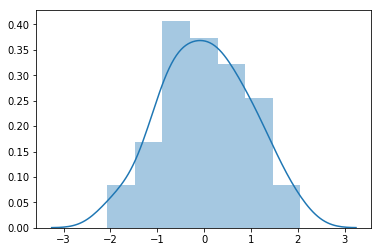%0A)

## Plotting bivariate distributions<a href="#Plotting-bivariate-distributions" class="anchor-link">¶</a>

The easiest way to visualize a bivariate distribution in seaborn is to
use the jointplot() function, which creates a multi-panel figure that
shows both the bivariate (or joint) relationship between two variables
along with the univariate (or marginal) distribution of each on separate
axes.

In \[19\]:

    mean, cov = [0, 1], [(1, .5), (.5, 1)]
    data = np.random.multivariate_normal(mean, cov, 200)
    df = pd.DataFrame(data, columns=["x", "y"])

**Basic scatter plots.** The most familiar way to visualize a bivariate
distribution is a scatterplot, where each observation is shown with
point at the x and y values. You can draw a scatterplot with the
matplotlib plt.scatter function, and it is also the default kind of plot
shown by the jointplot() function:

In \[20\]:

    sns.jointplot(x="x", y="y", data=df)

Out\[20\]:

    <seaborn.axisgrid.JointGrid at 0x7fb1b8f321d0>

![](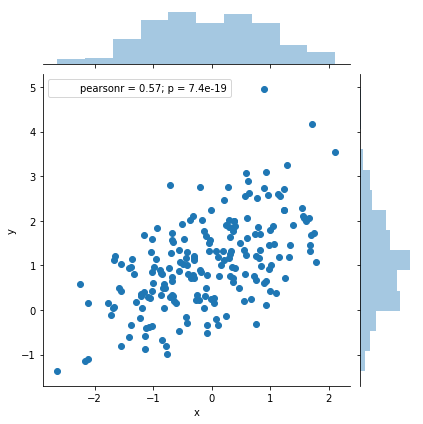%0A)

**Hexbin plots.** The bivariate analogue of a histogram is known as a
“hexbin” plot, because it shows the counts of observations that fall
within hexagonal bins. This plot works best with relatively large
datasets. It’s availible through the matplotlib plt.hexbin function and
as a style in jointplot()

In \[21\]:

    sns.jointplot(x="x", y="y", data=df, kind="hex")

Out\[21\]:

    <seaborn.axisgrid.JointGrid at 0x7fb1b8dda6d8>

![](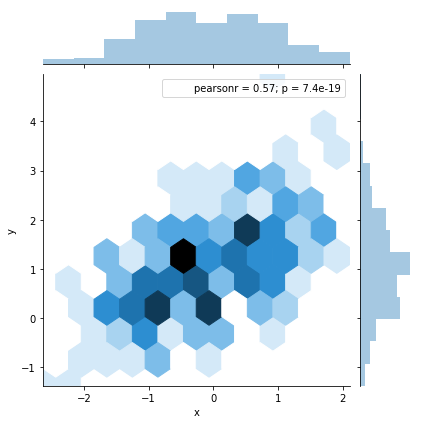%0A)

**Kernel density estimation.** It is also posible to use the kernel
density estimation procedure described above to visualize a bivariate
distribution. In seaborn, this kind of plot is shown with a contour plot
and is available as a style in jointplot()

In \[22\]:

    sns.jointplot(x="x", y="y", data=df, kind="kde")

Out\[22\]:

    <seaborn.axisgrid.JointGrid at 0x7fb1b8d8b898>

![](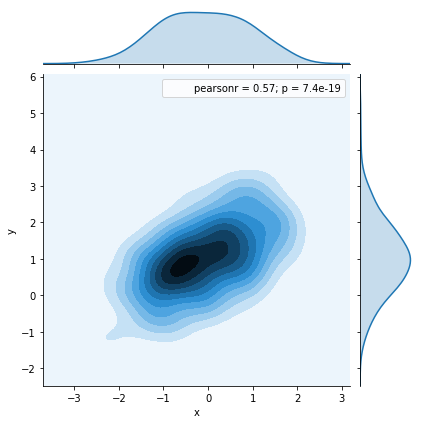%0A)

## Visualizing pairwise relationships in a dataset<a href="#Visualizing-pairwise-relationships-in-a-dataset"
class="anchor-link">¶</a>

To plot multiple pairwise bivariate distributions in a dataset, you can
use the pairplot() function. This creates a matrix of axes and shows the
relationship for each pair of columns in a DataFrame. by default, it
also draws the univariate distribution of each variable on the diagonal
Axes:

In \[23\]:

    sns.pairplot(flora)

Out\[23\]:

    <seaborn.axisgrid.PairGrid at 0x7fb1b8b58748>

![](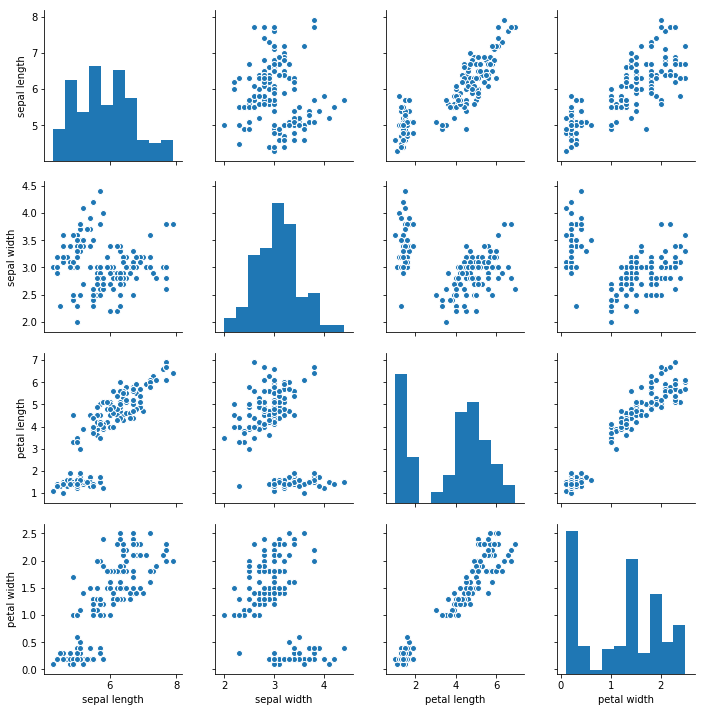%0A)

In \[24\]:

    # We can add colors to different species
    sns.pairplot(flora, hue="species")

Out\[24\]:

    <seaborn.axisgrid.PairGrid at 0x7fb1b842b278>

![](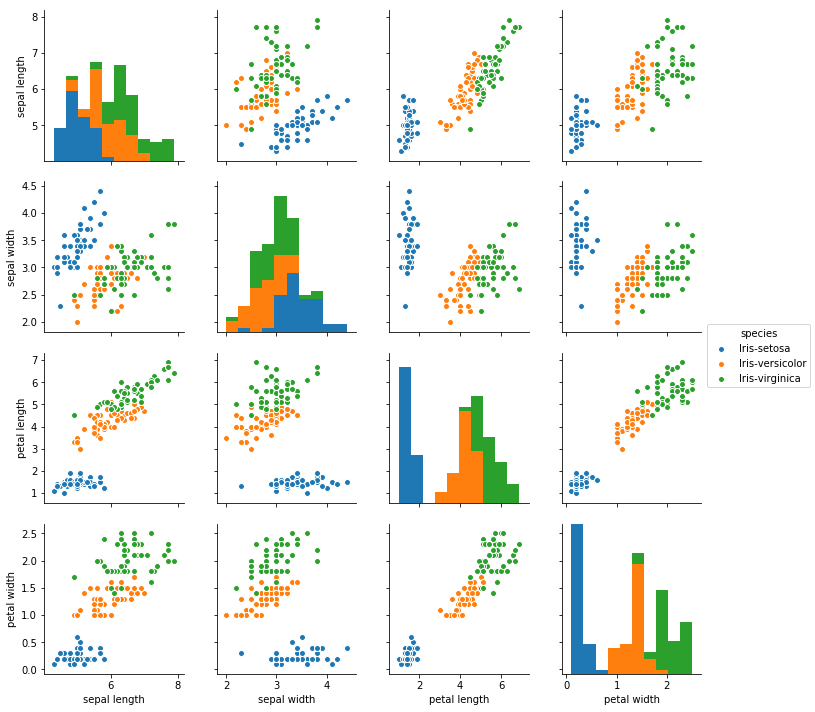%0A)

### Visualizing linear relationships<a href="#Visualizing-linear-relationships" class="anchor-link">¶</a>

In \[25\]:

    tips = pd.read_csv("tips.csv")
    tips.head()

Out\[25\]:

|     | total_bill | tip  | sex    | smoker | day | time   | size |
|-----|------------|------|--------|--------|-----|--------|------|
| 0   | 16.99      | 1.01 | Female | No     | Sun | Dinner | 2    |
| 1   | 10.34      | 1.66 | Male   | No     | Sun | Dinner | 3    |
| 2   | 21.01      | 3.50 | Male   | No     | Sun | Dinner | 3    |
| 3   | 23.68      | 3.31 | Male   | No     | Sun | Dinner | 2    |
| 4   | 24.59      | 3.61 | Female | No     | Sun | Dinner | 4    |

We can use the function `regplot` to show the linear relationship
between total_bill and tip. It also shows the 95% confidence interval.

In \[26\]:

    sns.regplot(x="total_bill", y="tip", data=tips)

Out\[26\]:

    <matplotlib.axes._subplots.AxesSubplot at 0x7fb1b7d43080>

![](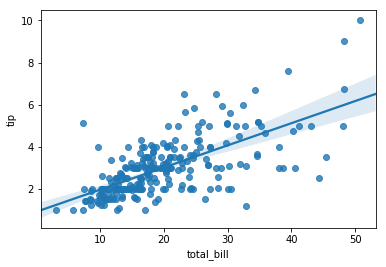%0A)

### Visualizing higher order relationships<a href="#Visualizing-higher-order-relationships"
class="anchor-link">¶</a>

In \[27\]:

    anscombe = pd.read_csv("anscombe.csv")
    sns.regplot(x="x", y="y", data=anscombe[anscombe["dataset"] == "II"])

Out\[27\]:

    <matplotlib.axes._subplots.AxesSubplot at 0x7fb1b7cc9dd8>

![](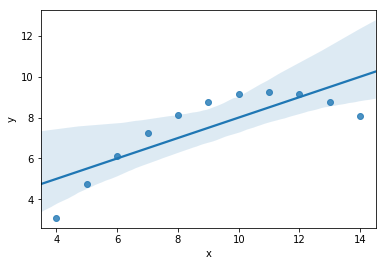%0A)

The plot clearly shows that this is not a good model. Let's try to fit a
polynomial regression model with degree 2.

In \[28\]:

    sns.regplot(x="x", y="y", data=anscombe[anscombe["dataset"] == "II"], order=2)

Out\[28\]:

    <matplotlib.axes._subplots.AxesSubplot at 0x7fb1b7c29da0>

![](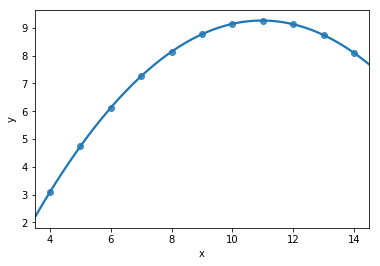%0A)

**Strip plots.** This is similar to scatter plot but used when one
variable is categorical.

In \[29\]:

    sns.stripplot(x="day", y="total_bill", data=tips)

Out\[29\]:

    <matplotlib.axes._subplots.AxesSubplot at 0x7fb1b7c50358>

![](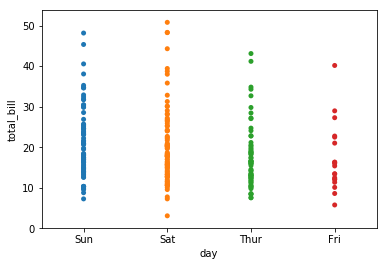%0A)

**Box plots.**

In \[30\]:

    sns.boxplot(x="day", y="total_bill", hue="time", data=tips)

Out\[30\]:

    <matplotlib.axes._subplots.AxesSubplot at 0x7fb1b7c03940>

![](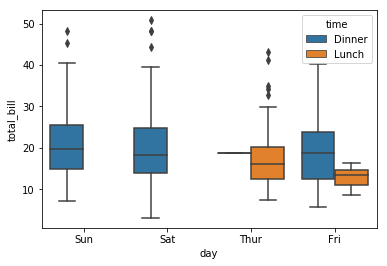%0A)

**Bar plots.**

In \[31\]:

    titanic = pd.read_csv("titanic.csv")
    sns.barplot(x="sex", y="survived", hue="class", data=titanic)

Out\[31\]:

    <matplotlib.axes._subplots.AxesSubplot at 0x7fb1b7accf98>

![](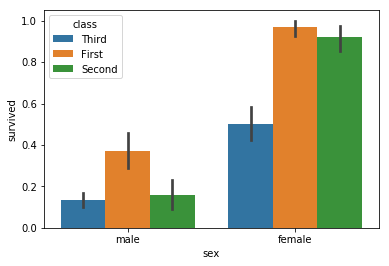%0A)

**Fin!** That ends this tour of basic plotting functionality available
to you in Python. It only scratches the surface of what is possible.
We'll explore more advanced features in future labs, but in the
meantime, we encourage you to play with the code in this notebook and
try to generate your own visualizations of datasets you care about!

Although this notebook did not require you to write any code, go ahead
and "submit" it for grading. You'll effectively get "free points" for
doing so: the code cell below gives it to you.

In \[32\]:

    # Test cell: `freebie_test`
    assert True